<a href="https://colab.research.google.com/github/hlee63kent/Hye-Won-Lee_AdvancedMachineLearning/blob/main/Hyewon_Lee_Advance_Machine_Learning2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

!nvidia-smi

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Sat Mar  7 16:24:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|          

In [7]:
!rm -rf /content/data /content/work
!mkdir -p /content/data /content/work
!cp "/content/drive/MyDrive/dogs-vs-cats.zip" /content/
!unzip -q /content/dogs-vs-cats.zip -d /content/data
!unzip -q /content/data/train.zip -d /content/data
!ls /content/data

sampleSubmission.csv  test1.zip  train	train.zip


In [8]:
import os
import gc
import json
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_folder = Path("/content/data/train")
drive_root = Path("/content/drive/MyDrive/cats_dogs_assignment2")
drive_root.mkdir(parents=True, exist_ok=True)

In [9]:
for fname in os.listdir(train_folder):
    fpath = train_folder / fname
    try:
        img = Image.open(fpath)
        img.verify()
    except:
        try:
            os.remove(fpath)
        except:
            pass

In [10]:
cats_all = [p for p in train_folder.iterdir() if p.is_file() and p.name.startswith("cat.")]
dogs_all = [p for p in train_folder.iterdir() if p.is_file() and p.name.startswith("dog.")]

random.shuffle(cats_all)
random.shuffle(dogs_all)

print(len(cats_all), len(dogs_all))

12500 12500


In [11]:
def build_split(dst_root, train_n, val_n=500, test_n=500):
    dst_root = Path(dst_root)
    if dst_root.exists():
        shutil.rmtree(dst_root)

    for split in ["train", "validation", "test"]:
        for cls in ["cats", "dogs"]:
            (dst_root / split / cls).mkdir(parents=True, exist_ok=True)

    total_need = train_n + val_n + test_n
    if len(cats_all) < total_need or len(dogs_all) < total_need:
        raise RuntimeError("Not enough images.")

    def copy_many(files, outdir):
        for f in files:
            shutil.copy2(f, outdir / f.name)

    copy_many(cats_all[0:train_n], dst_root / "train" / "cats")
    copy_many(dogs_all[0:train_n], dst_root / "train" / "dogs")

    copy_many(cats_all[train_n:train_n+val_n], dst_root / "validation" / "cats")
    copy_many(dogs_all[train_n:train_n+val_n], dst_root / "validation" / "dogs")

    copy_many(cats_all[train_n+val_n:train_n+val_n+test_n], dst_root / "test" / "cats")
    copy_many(dogs_all[train_n+val_n:train_n+val_n+test_n], dst_root / "test" / "dogs")

    return dst_root

In [12]:
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
])

In [13]:
def make_ds_basic(exp_dir, augment=True):
    exp_dir = Path(exp_dir)

    train_ds = keras.utils.image_dataset_from_directory(
        exp_dir / "train",
        labels="inferred",
        label_mode="binary",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED
    )

    val_ds = keras.utils.image_dataset_from_directory(
        exp_dir / "validation",
        labels="inferred",
        label_mode="binary",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    test_ds = keras.utils.image_dataset_from_directory(
        exp_dir / "test",
        labels="inferred",
        label_mode="binary",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    norm = layers.Rescaling(1./255)

    def prep_train(x, y):
        x = norm(x)
        if augment:
            x = data_aug(x, training=True)
        return x, y

    def prep_eval(x, y):
        return norm(x), y

    train_ds = train_ds.map(prep_train, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.map(prep_eval, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
    test_ds = test_ds.map(prep_eval, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds

In [14]:
def make_ds_vgg(exp_dir, augment=True):
    exp_dir = Path(exp_dir)

    train_ds = keras.utils.image_dataset_from_directory(
        exp_dir / "train",
        labels="inferred",
        label_mode="binary",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED
    )

    val_ds = keras.utils.image_dataset_from_directory(
        exp_dir / "validation",
        labels="inferred",
        label_mode="binary",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    test_ds = keras.utils.image_dataset_from_directory(
        exp_dir / "test",
        labels="inferred",
        label_mode="binary",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    def prep_train(x, y):
        x = tf.cast(x, tf.float32)
        if augment:
            x = data_aug(x, training=True)
        return preprocess_input(x), y

    def prep_eval(x, y):
        x = tf.cast(x, tf.float32)
        return preprocess_input(x), y

    train_ds = train_ds.map(prep_train, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.map(prep_eval, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
    test_ds = test_ds.map(prep_eval, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds

In [15]:
def build_scratch():
    model = keras.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=keras.optimizers.RMSprop(1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [16]:
def build_vgg(fine_tune=False, fine_tune_at="block5_conv1"):
    conv_base = VGG16(weights="imagenet", include_top=False, input_shape=(*IMG_SIZE, 3))
    conv_base.trainable = False

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = conv_base(inputs, training=False)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.RMSprop(2e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    if fine_tune:
        conv_base.trainable = True
        set_trainable = False
        for layer in conv_base.layers:
            if layer.name == fine_tune_at:
                set_trainable = True
            layer.trainable = set_trainable

        model.compile(
            optimizer=keras.optimizers.RMSprop(1e-5),
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )

    return model

In [17]:
def train_eval(model, train_ds, val_ds, test_ds, epochs, ckpt_path):
    callbacks = [
        keras.callbacks.ModelCheckpoint(
            ckpt_path,
            save_best_only=True,
            monitor="val_accuracy",
            mode="max"
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=5,
            mode="max",
            restore_best_weights=True
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        verbose=2,
        callbacks=callbacks
    )

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    best_val = float(np.max(history.history["val_accuracy"]))

    return history, best_val, float(test_acc)

In [18]:
results = []
train_sizes = [1000, 5000, 10000]

for n in train_sizes:
    exp_dir = build_split(f"/content/work/exp_{n}", train_n=n, val_n=500, test_n=500)

    train_ds, val_ds, test_ds = make_ds_basic(exp_dir, augment=True)
    m1 = build_scratch()
    h1, best_val1, test_acc1 = train_eval(
        m1, train_ds, val_ds, test_ds,
        epochs=30,
        ckpt_path=f"/content/best_scratch_{n}.keras"
    )
    m1.save(drive_root / f"scratch_{n}.keras")
    with open(drive_root / f"history_scratch_{n}.json", "w") as f:
        json.dump(h1.history, f)

    results.append({
        "model": "scratch",
        "train_n_per_class": n,
        "best_val_acc": best_val1,
        "test_acc": test_acc1
    })

    del train_ds, val_ds, test_ds, m1, h1
    keras.backend.clear_session()
    gc.collect()

    train_ds_v, val_ds_v, test_ds_v = make_ds_vgg(exp_dir, augment=True)
    m2 = build_vgg(fine_tune=False)
    h2, best_val2, test_acc2 = train_eval(
        m2, train_ds_v, val_ds_v, test_ds_v,
        epochs=20,
        ckpt_path=f"/content/best_vgg_frozen_{n}.keras"
    )
    m2.save(drive_root / f"vgg_frozen_{n}.keras")
    with open(drive_root / f"history_vgg_frozen_{n}.json", "w") as f:
        json.dump(h2.history, f)

    results.append({
        "model": "vgg_frozen",
        "train_n_per_class": n,
        "best_val_acc": best_val2,
        "test_acc": test_acc2
    })

    del train_ds_v, val_ds_v, test_ds_v, m2, h2
    keras.backend.clear_session()
    gc.collect()

    train_ds_v, val_ds_v, test_ds_v = make_ds_vgg(exp_dir, augment=True)
    m3 = build_vgg(fine_tune=True, fine_tune_at="block5_conv1")
    h3, best_val3, test_acc3 = train_eval(
        m3, train_ds_v, val_ds_v, test_ds_v,
        epochs=10,
        ckpt_path=f"/content/best_vgg_finetune_{n}.keras"
    )
    m3.save(drive_root / f"vgg_finetune_{n}.keras")
    with open(drive_root / f"history_vgg_finetune_{n}.json", "w") as f:
        json.dump(h3.history, f)

    results.append({
        "model": "vgg_finetune",
        "train_n_per_class": n,
        "best_val_acc": best_val3,
        "test_acc": test_acc3
    })

    del train_ds_v, val_ds_v, test_ds_v, m3, h3
    keras.backend.clear_session()
    gc.collect()

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Epoch 1/30
63/63 - 25s - 403ms/step - accuracy: 0.4945 - loss: 0.6947 - val_accuracy: 0.5010 - val_loss: 0.6921
Epoch 2/30
63/63 - 14s - 230ms/step - accuracy: 0.5230 - loss: 0.6919 - val_accuracy: 0.5000 - val_loss: 0.6913
Epoch 3/30
63/63 - 15s - 238ms/step - accuracy: 0.5255 - loss: 0.6902 - val_accuracy: 0.5040 - val_loss: 0.6889
Epoch 4/30
63/63 - 14s - 228ms/step - accuracy: 0.5395 - loss: 0.6897 - val_accuracy: 0.5020 - val_loss: 0.6868
Epoch 5/30
63/63 - 14s - 227ms/step - accuracy: 0.5600 - loss: 0.6854 - val_accuracy: 0.5020 - val_loss: 0.6886
Epoch 6/30
63/63 - 15s - 234ms/step - accuracy: 0.5665 - loss: 0.6804 - val_accuracy: 0.5300 - val_loss: 0.6780
Epoch 7/30
63/63 - 14s - 228ms/step - accuracy: 0.6015 - loss: 0.6721 - val_accuracy: 0.5040 - val_loss: 0.7089
Epoch 8/30
63/63 - 14s - 227ms/step - accuracy: 0.5930 - loss: 0.6670 - val_accuracy: 0.5850 

In [19]:
df = pd.DataFrame(results).sort_values(["model", "train_n_per_class"])
df.to_csv(drive_root / "results_summary.csv", index=False)
df.to_csv(drive_root / "results_summary_valonly.csv", index=False)
df

,model,train_n_per_class,best_val_acc,test_acc
0,scratch,1000,0.642,0.663
3,scratch,5000,0.796,0.777
6,scratch,10000,0.832,0.828
2,vgg_finetune,1000,0.958,0.962
5,vgg_finetune,5000,0.979,0.975
8,vgg_finetune,10000,0.979,0.980
1,vgg_frozen,1000,0.971,0.967
4,vgg_frozen,5000,0.975,0.970
7,vgg_frozen,10000,0.974,0.983


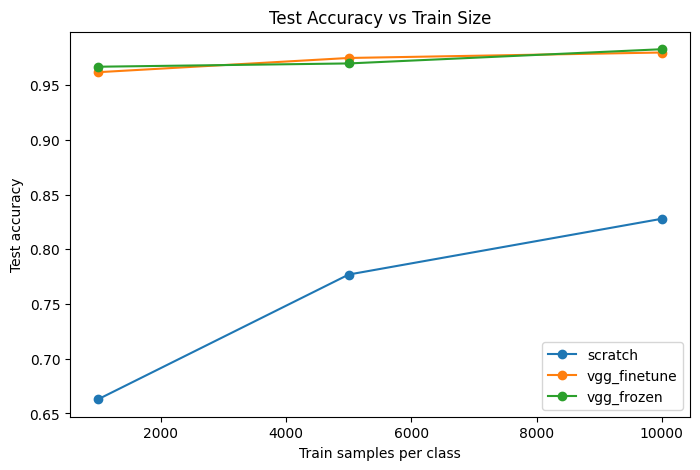

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
for model_name in df["model"].unique():
    sub = df[df["model"] == model_name]
    plt.plot(sub["train_n_per_class"], sub["test_acc"], marker="o", label=model_name)

plt.xlabel("Train samples per class")
plt.ylabel("Test accuracy")
plt.title("Test Accuracy vs Train Size")
plt.legend()
plt.show()

In [21]:
!ls /content/drive/MyDrive/cats_dogs_assignment2

history_scratch_10000.json	 results_summary_valonly.csv
history_scratch_1000.json	 scratch_10000.keras
history_scratch_5000.json	 scratch_1000.keras
history_vgg_finetune_10000.json  scratch_5000.keras
history_vgg_finetune_1000.json	 vgg_finetune_10000.keras
history_vgg_finetune_5000.json	 vgg_finetune_1000.keras
history_vgg_frozen_10000.json	 vgg_finetune_5000.keras
history_vgg_frozen_1000.json	 vgg_frozen_10000.keras
history_vgg_frozen_5000.json	 vgg_frozen_1000.keras
results_summary.csv		 vgg_frozen_5000.keras


In [22]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/cats_dogs_assignment2/results_summary.csv")
df

,model,train_n_per_class,best_val_acc,test_acc
0,scratch,1000,0.642,0.663
1,scratch,5000,0.796,0.777
2,scratch,10000,0.832,0.828
3,vgg_finetune,1000,0.958,0.962
4,vgg_finetune,5000,0.979,0.975
5,vgg_finetune,10000,0.979,0.980
6,vgg_frozen,1000,0.971,0.967
7,vgg_frozen,5000,0.975,0.970
8,vgg_frozen,10000,0.974,0.983


In [26]:
df.sort_values("test_acc", ascending=False)

,model,train_n_per_class,best_val_acc,test_acc
8,vgg_frozen,10000,0.974,0.983
5,vgg_finetune,10000,0.979,0.980
4,vgg_finetune,5000,0.979,0.975
7,vgg_frozen,5000,0.975,0.970
6,vgg_frozen,1000,0.971,0.967
3,vgg_finetune,1000,0.958,0.962
2,scratch,10000,0.832,0.828
1,scratch,5000,0.796,0.777
0,scratch,1000,0.642,0.663
